# Computational Partial Differential Equations

## Irene S. Nelson, PhD

## Day 2: General Relativity and GRMHD

### General Relativity Primer

In the early 20th century, physics had a problem. Physicists had hypothesized that light must propagate through some medium known as the aether. However, when Michelson and Morley set out to try and detect this aether by measuring small differences in the speed of light at different points in the Earth's orbit around the sun. However, much to their surprise,  they found that, no matter what, the speed of light remained constant. Albert Einstein followed this startling realization to its logical conclusion: if the speed of light in a vacuum is *always* constant, then the flow of time and distances between fixed points *cannot* be constant. Instead, they depend on the speed of the observer. Ultimately, this led to the development of Einstein's special theory of relativity.

Seeking to incorporate gravity into his theory of relativity, he noted that an observer in a box would be unable to tell whether the box was in a gravitational field or constantly accelerating. This insight, combined with special relativity, showed Einstein that the deeper into a gravitational field an observer is, the slower time passes for them. This eventually led Einstein to the general theory of relativity as we know it today.

In general relativity, space and time are combined into a single concept called spacetime, which is often visualized as a four-dimensional fabric that can stretch and deform in response the distribution of mass and energy in the spacetime. In turn, this distorted spacetime affects the paths of objects moving within it. That is, matter tells spacetime how to bend, and spacetime tells matter how to move. The standard demonstration for this concept imagines spacetime as a stretched rubber sheet. When a bowling ball is placed on the sheet, it bends the sheet, pulling it downwards. Then, when we try to roll a smaller ball on the sheet in a straight line, we find that the ball's path is bent around the bowling ball. In much the same way, when an asteroid approaches near the Earth, we see its orbit bent around our planet. Less obviously, we can even see light rays bend around the sun, as was first observed by Dyson and Eddington in 1919.

Since then, Einstein's theory has been experimentally verified over and over again. Of course, in order to experimentally verify a theory, we must first make predictions with that theory. In GR, these predictions are made by finding solutions to the Einstein equations. Unfortunately, this is easier said than done. There are very few known exact solutions to this set of equations, and as mentioned previously, these solutions do not correspond to physically-likely scenarios. As such, we often use approximate computational solutions instead.

### A Note on Units

The standard convention in GR is to use what we call "geometrized units". In this system, define the speed of light $c$ and universal gravitational constant $G$ to both be exactly one. Doing so allows us most quantities of interest (including masses and times) in units of length. When we do this, we find that one second is $2.998 \times 10^8$ meters and one kilogram is $7.426 \times 10^{-28}$ meters. 

This will also allow us to express many quantities as multiples of black hole mass. For example, in a simulation, the mass of a black hole is simple called $M$. The masses of other black holes can then be defined defined as a multiple of the first black holes mass, like $2M$ or $M/2$. We can also express the distance between two black holes as a multiple of their mass, e.g. $50M$. The effects we observe are scale invariant: no matter what the value of $M$ is, if we place two black holes with that mass $50M$ apart, we will observe the same effects, whether they are two millimeter-mass black holes 50 mm apart or two kilometer-mass black holes 50 km apart.

### Black Hole Simulations

General relativity, and, in particular, the interactions between space, time, gravity, and mass and energy, are described by the Einstein field equations. These equations show us how the distribution of matter and energy in the universe are related to the *metric tensor*, $g_{\mu \nu}$. The metric tensor describes how spacetime is curved in by detailing how to calculate the distance between different points in space and time.

To determine how any system behaves in general relativity, we must find a solution to the Einstein field equations. Unfortunately, there are very few exact solutions, and the exact solutions that are known are limited to scenarios such as a gravitational wave propagating through empty space or a single black hole. More complicated systems will require us to numerically integrate the equations to find an approximate solution. 

To do so, we will use a very powerful code package called the Einstein Toolkit (ETK), which is part of the Cactus Computational Toolkit (CCTK). The CCTK is made up of individual modules known as "thorns" which provide the functionality we need. There are thorns for setting up the numerical grid, for solving for initial data, applying boundary conditions, and so on. Cactus provides a common interface to allow all these thorns to interact with each other and share data. 

Below are links to some example simulations for the Toolkit.

https://einsteintoolkit.org/gallery.html

https://einsteintoolkit.org/gallery/bbh/index.html

However, we cannot apply the usual techniques of numerical integration just yet. As discussed previously, those techniques assume that we have a grid of points on space, and that the locations of those points stay constant, and that time flows uniformly everywhere in our computational domain. But as we just mentioned, this is not the case in general relativity. So, we must break up the rank-four metric tensor $g_{\mu \nu}$, slicing up spacetime into layers. When we do so, we get the rank-three metric tensor $\gamma_{i j}$, which describes the curvature of spacetime in a single layer, the shift vector $\beta_{i}$, which describes how a grid cell's position will change in between slices, and the lapse $\alpha$, which describes how much time will pass at a point in between slices. 

There are infinitely many ways we can choose to define our coordinate system in this way. Thus, we must be very careful about how we talk about the numbers that we will pass into our code; not all the parameters we set will have a readily interpretable physical meaning. In general, it is best to focus in invariant quantities like the dimensionless spin parameter. Two observers might not even agree whether two events are simultaneous in general relativity, but they will always agree on the spin of a black hole.

#### The 3+1 Decomposition:
Rinne, Oliver. (2014). Numerical and analytical methods for asymptotically flat spacetimes. 

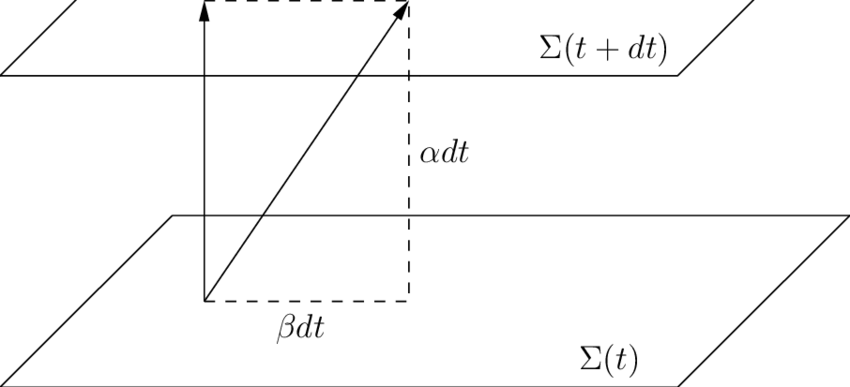

In [1]:
from IPython.display import Image
from IPython.core.display import HTML 
Path = "shooting_blackholes/"

Image(Path + "3-1-decomposition-with-unit-timelike-normal-n-a-lapse-function-a-and-shift-vector-b-i.png")

### Induced Black Hole Spin

On Earth, coastal areas experience a tidal cycle twice per day. In many areas, the timing of these tides indicates a clear connection between the tides and the moon: high tide occurs both when the moon is directly overhead, and then again, about twelve hours later, when the moon is directly over the other side of the world. 

Classical gravity offers a clear insight into why these things are connected. The gravitational force between any two objects depends on the mass of those objects and the distance between them. Because the gravity from one object pulls on all other objects, the moon is pulling on the planet as well as the oceans. However, the force of this pull decreases quickly the farther you get from the moon. Thus, the part of the ocean directly underneath it (i.e. closest to it) is experiences a stronger pull than Earth does, and the part of the ocean on the other side of the planet experiences a weaker pull. This causes the two tidal bulges to form in Earth's oceans, giving us the familiar cycle of tides.

But the Earth is also spinning. As the Earth rotates, it pulls the tidal bulges along with it, so the tidal bulges aren't directly in line with the moon. The moon's gravity pulls back on them, however. Since the tidal bulges are no longer on the line between the centers of the Earth and moon, the moon exerts a torque on the planet, decreasing its angular momentum. In effect, the moon pulling on the Earth's tides results in the day on Earth constantly getting a little bit longer.

This doesn't just apply to the things on the Earth, though. It applies to the Earth itself, as well. This difference in force subtly stretches out the Earth. This effect can also be seen elsewhere in the Solar System, often to much more dramatic effect. Consider the moons of Jupiter. On Io, this constant stretching creates friction within the moon that heats it up, resulting in extreme volcanic activity. The images of the surface of Io taken by the Voyager probes are no longer accurate because the surface is being remodeled all the time. On Europa, this process creates enough heat to maintain a liquid ocean underneath miles of ice.

This leads us to an interesting question. If physical bodies can have their angular momentum changed by tidal effects, can the same thing happen to a black hole? At first, we might think that the answer is no, since all the mass in a black hole is concentrated at a single point called the singularity, and tides involve the gravitational force acting with different strengths at different distances.

However, that is only true in classical mechanics. In general relativity, gravity is a deformation in the fabric of spacetime. When one black hole deforms spacetime around it, it can distort nearby features in spacetime. In fact, when two black holes get close to merging, we can see that their event horizons are distorted by each other, eventually forming a two-lobed structure in the first instant after they merge. So perhaps "black hole tides" are not as unlikely a concept as we first thought?

#### Terrestrial Tides
https://commons.wikimedia.org/wiki/File:Tide_overview.svg

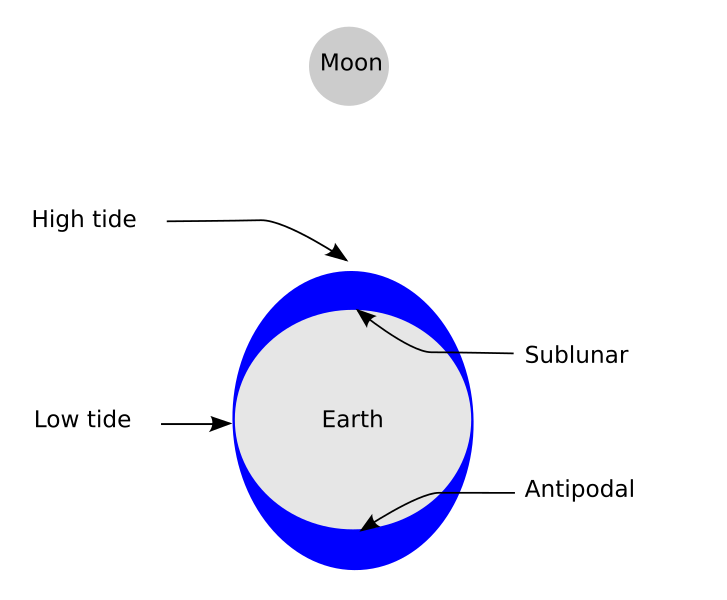

In [2]:
Image(Path + "Tide_overview.svg.png")

### Example: Induced Black Hole Spin

To answer this question, we will set up a simple experiment. We will start with two equal mass, non-spinning black holes. (This sets up the simplest case with which we could answer this question.) We will also give them some initial momentum, shooting them towards each other. Our goal is to set the black holes on scattering trajectories: we want the black holes to interact in the strong-field regime, where the relativistic gravitational fields are strongest, but we also want to be careful not to let them merge. 

So, the input parameters that are controlling will be the initial separation of the black holes, their initial speed, and the angle at which we shoot them.

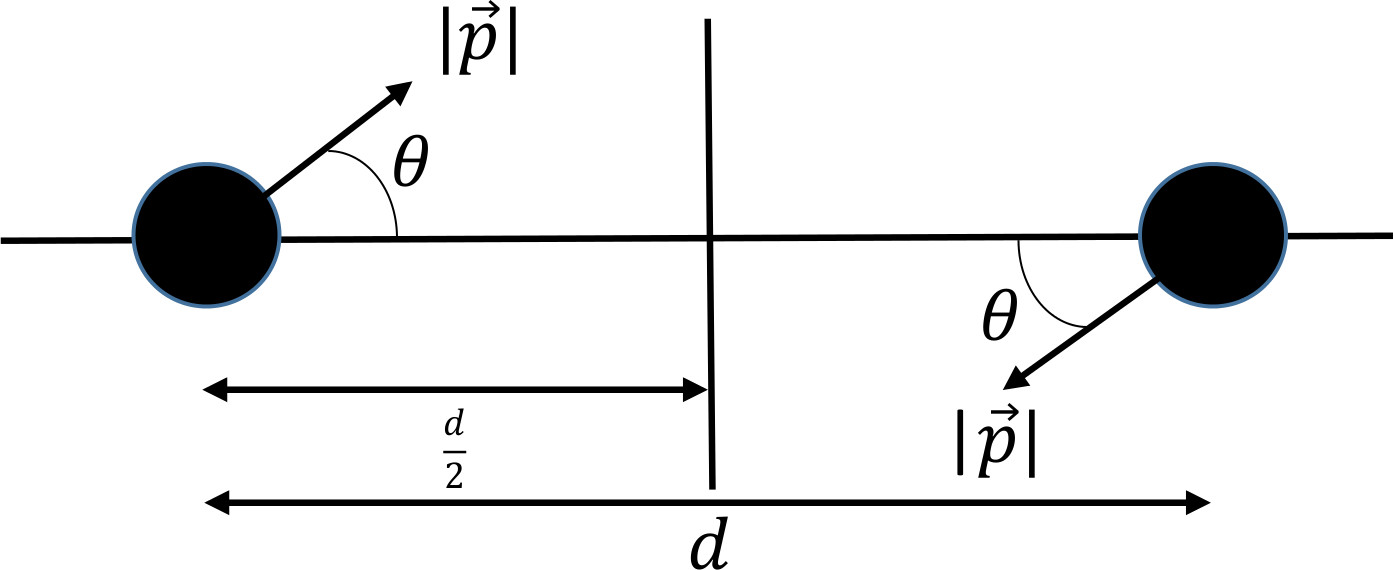

In [3]:
Image(Path + "InitialDataSchematic.jpg")

We will choose to set the initial separation of the black holes to $100 M$. It is important to start with the black holes quite far apart. This is because of a peculiarity with how we calculate the initial data. When the toolkit generates our initial data, it will set up two moving black holes and add their metrics together over a background of flat spacetime. However, in reality, the spacetime metric for this scenario would include contributions from their movement from infinite time beforehand. 

Fortunately, the evolution equations are programmed in such a way that these inconsistencies will soon be resolved as the simulation advances. However, this also creates unphysical "junk" gravitational waves that propagate outwards (even exceeding the speed of light!); this is part of why it is vitally important to make sure that our boundary conditions are set up correctly. Our simulation's outer boundary must allow the junk radiation to leave our computational domain, or else it could reflect back and interfere with the simulation.

Thus, while the junk radiation is ultimately inconsequential if we do everything correctly, it is still important to make sure the simulation has time to stabilize before the black holes strongly interact.

We will also set a coordinate velocity of $0.98$. (Ultimately, this number does not represent something observable). We will also choose an angle $\theta = 0.0550$.

Exploring the included parameter file
```Shooting_BlackHoles_using_TwoPunctures_theta_5.5000e-02__vel_9.8000e-01__sepRadius_5.0000e+01.par```

Thorns of Note:
- ADMBase, ML_BSSN: Solves the Einstein Equations
- AHFinderDirect: Calculates information about the apparent horizons
- Carpet: manages the coordinate grid
    - CarpetIOASCII: Outputs selected quantities
    - CarpetIOScalar: More outputs
- CoordBase: Sets the extent and resolution of the coarsest grid
- CarpetRegrid2: Controls the refinement levels
- MoL: the numerical integrator itself!
- PunctureTracker: Sets the initial position of the black holes and tracks their position
- QuasiLocalMeasures: Calculates the mass and spin of the black holes
- TwoPunctures: Our initial data of choice
- weylscal4: calculates gravitational wave data

#### Adaptive Mesh Refinement
Janiuk, Agnieszka & Charzyński, Szymon. (2016). Simulations of coalescing black holes. 

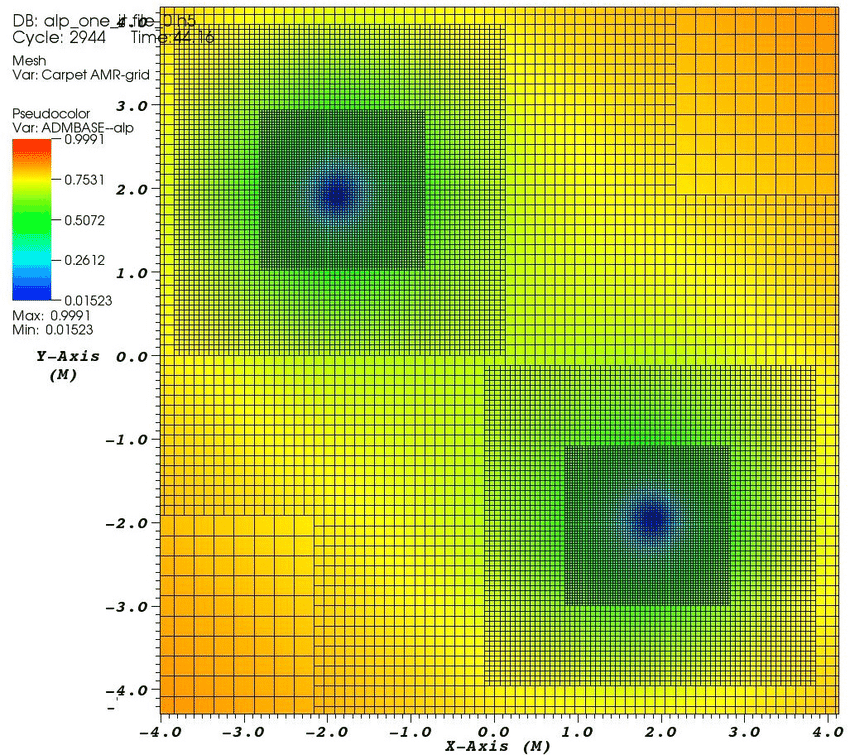

In [4]:
Image(Path + "Adaptive-mesh-refinement-in-the-simulation-of-merging-black-holes.png")

After submitting this parameter file with the included job submission script, we are left with numerous text files.

We will focus on two in particular:
- `BH_diagnostics.ah1.gp` contains information about the apparent horizons of the black holes
- `qlm_spin[0].norm2.asc` has information about the spin of the black holes.

Also of note are the files `mp_psi4_*.asc` which contain the data we would need to use to analyse any gravitational waves emitted by this system.

We will start by analysing the trajectory of our black holes.

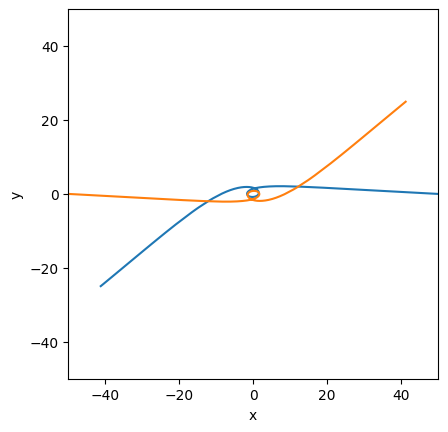

In [5]:
import matplotlib.pyplot as plt
import numpy as np

Path = "shooting_blackholes/ABEoutput_directory-Shooting_BlackHoles_using_TwoPunctures_theta_5.5000e-02__vel_9.8000e-01__sepRadius_5.0000e+01.par-mr/"
diagnostics1 = np.loadtxt(Path + "BH_diagnostics.ah1.gp")
diagnostics2 = np.loadtxt(Path + "BH_diagnostics.ah2.gp")
plt.figure()
plt.plot(diagnostics1[:,2],diagnostics1[:,3])
plt.plot(diagnostics2[:,2],diagnostics2[:,3])
plt.axis([-50, 50, -50, 50])
# plt.axis([-10, 10, -10, 10])
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


We will also take a look at the spin data; the time series clearly shows that we do in fact induce a final spin of about $0.03$.

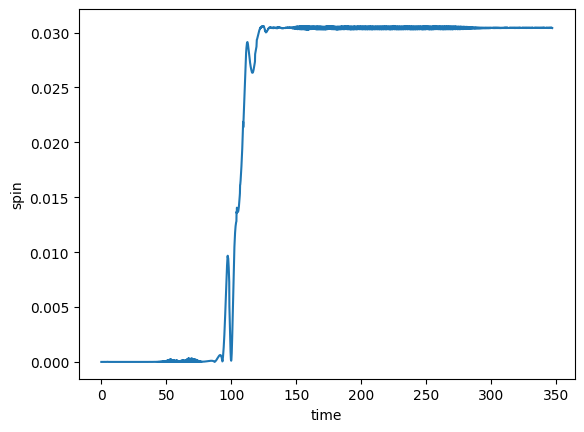

In [6]:
spin = np.loadtxt(Path + "qlm_spin[0].norm2.asc")
plt.figure()
plt.plot(spin[:,1],spin[:,2])
plt.xlabel('time')
plt.ylabel('spin')
plt.show()

### Array Jobs: Carrying Out a Study

But this is not the end of the story. In answering our first question, we have found many more. We will discuss  two in particular:
1. Does the induced spin change as the black holes interact deeper in the strong field regime (i.e. as we decrease the shooting angle)?
2. Does the induced spin change as we impart a different initial velocity to the black holes?

To answer the first question we might set up an array job to try many different shooting angles $\theta$ at the same time. When we do so, we will discover that as we decrease the shooting angle, the final induced spin increases. So, to try to find the highest spin, we will want to try and find the angle that gets us as close to a merger as possible while still allowing the final black holes to escape to a greater distance.

This is an ideal case to create an array job.

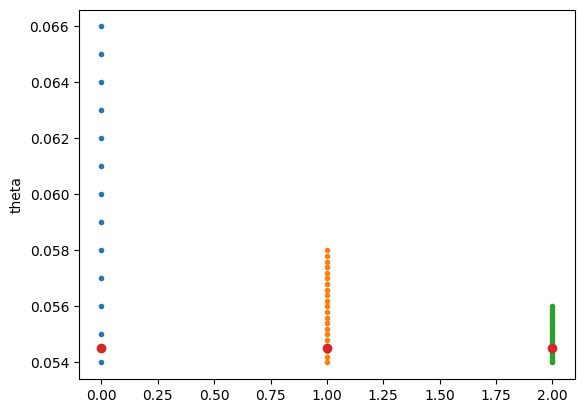

In [7]:
angles0 = np.arange(0.054,0.066,0.001)
step0 = np.zeros_like(angles0)

angles1 = np.arange(0.054,0.058,0.0002)
step1 = np.zeros_like(angles1)+1

angles2 = np.arange(0.054,0.056,0.0001)
step2 = np.zeros_like(angles2)+2

plt.figure()
plt.plot(step0,angles0,'.')
plt.plot(step1,angles1,'.')
plt.plot(step2,angles2,'.')
plt.plot([0,1,2],[0.0545,0.0545,0.0545],'o')
plt.ylabel("theta")
plt.show()

When we want to explore how the induced spin changes with different initial velocities, we will repeat this procedure with a different initial boost.

### Challenge: Find a Higher Final Spin

The highest spin that has been found with this setup is $0.20$, which is one-fifth of the maximum spin. However, it is very likely that it is possible to achieve a much higher spin. If you want to try to find a higher spin yourself, you will need to use a $v_0 > 1.5$. At your chosen initial speed, vary the angle to find the smallest $\theta$ that does *not* result in a merger. You will need to change the following parameters at the bottom of the parameter file.

```
TwoPunctures::par_P_plus[0]
TwoPunctures::par_P_minus[0]
TwoPunctures::par_P_plus[1]
TwoPunctures::par_P_minus[1]
```
The above parameters should be set to
$$\pm \frac{v_0}{2} \cos \theta$$
$$\pm \frac{v_0}{2} \sin \theta$$
in accordance with the initial data schematic above.

### Verifying Results

The fanciest simulation you can create is meaningless unless you can show that your results do, in fact, approximate reality, no matter how much memory or how many CPU hours you use. The codes that we have been using have been robustly tested to show that they can produce the expected results.

We will explore one method to do so using an exact solution from general relativistic force-free electrodynamics.

#### Stellar Remnants

We have already discussed one type of dead star, the black hole; we will briefly touch on the others.

Throughout a star's life, the inward pull of gravity is balance by the outward pressure from the fusion reactions taking place in its core. However, as a star ages, it begins to run out of hydrogen to fuse in its core and must start fusing heavier and heavier elements together. Eventually, the star will reach a point where the pressure at its core is insufficient to continue the fusion process, and the star dies. The crushing inward pressure from gravity wins, and the star collapses. The final state depends on the star's mass.

The least massive stars will shed their outer layers, forming a planetary nebula with a white dwarf at its center. More massive stars will explode violently in a supernova; the dense core left behind is more massive, and collapses into a denser neutron star. However, for the most massive stars, the dense remnant left behind becomes so dense that nothing can stop its complete collapse into a black hole.

#### General Relativistic Magnetohydrodynamics

When we want to study conducting fluids, we must combine Maxwell's equations of electromagnetism with the equations of fluid dynamics; this field is known as Magnetohydrodynamics (MHD). These equations describe systems like stars, magnetospheres, and the interstellar medium. However, we must take things a step farther if the conducting fluid we want to study involves either extremely fast speeds or extremely dense objects.

In such a case, we must also incorporate the Einstein field equations; the resulting system is called general relativistic magnetohydrodynamics. These equations describe some of the most extreme events in the known universe such as neutron star mergers. Simulations of such events were crucial to deciphering the signals detected on 17 August 2017, when we detected the first neutron star merger simultaneously in gravitational and electromagnetic waves (GW170817 and GRB 170817A), ushering in the era of multi-messenger astrophysics.

We will consider an example from a special case of GRMHD, general relativistics force-free electrodynamics.

#### General Relativistic Force-Free Electrodynamics

General relativistics force-free electrodynamics (GRFFE) is a special case of GRMHD in which the magnetic pressure dominates the gas pressure. Such systems occur in systems with intense gravitational and magnetic fields. Neutron star magnetospheres are an example of a system that can be well-approximated by GRFFE.

### Example: GRFFE Exact Wald

In order to explore one method of verifying that our code works as it should, we will examine the Exact Wald solution to the GRFFE equations. This solutions describes a single spinning black hole in a uniform magnetic field. A similar situation could occur in nature in a black hole-neutron star binary.

For our purposes, the most important thing about this solution is that it is time-independent; if our code were to work *perfectly*, as the simulation advances, everything should stay exactly the same.

This simulation will use:
- ShiftedKerrSchild: initial data for a single spinning black hole
- GiRaFFE: GRFFE solver
- GiRaFFEfood: GRFFE initial data

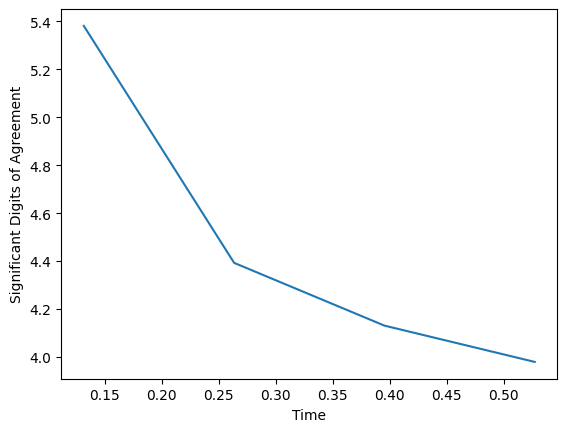

In [8]:
Bz = np.loadtxt("Exact_Wald/GiRaFFE_tests_ExactWald/Bz.maximum.asc")
Bz_exact = Bz[0,2]

plt.figure()
plt.plot(Bz[1:,1],1.0-np.log10(2.0*np.abs(Bz[1:,2]-Bz_exact)/(np.abs(Bz[1:,2])+np.abs(Bz_exact))))
plt.ylabel("Significant Digits of Agreement")
plt.xlabel("Time")
plt.show()

Naturally, our simulation is not perfect; no simulation ever will be. However, we can see even as the agreement drops off, it is approaching as asymptote at about 3 SDA, which is quite good for the resolution we chose. If we want, we can take the assessment of our code further with convergence analysis.

### Exercise: Convergence testing

Included in the materials for this workshop is the parameter file for a very simple code test using the Alfv&eacute;n wave. You can change the resolution by modifying the following parameters:
```
CoordBase::dx
CoordBase::dy
CoordBase::dz
```
The ideal way to do this is by dividing these numbers by 2 to create a medium-resolution simulation, then dividing by 2 again to create a high-resolution simulation. The output quantity of interest is $B^z$.
Run the simulation at each of the three resolutions and plot the difference in $B^z$ between the low and medium resolutions and medium and high resolutions to show that that as we increase the resolution, the simulation results are converging.

(Note: you will need to be careful when subtracting the different results from each other because they each have different numbers of points!)